# Base case — bivariate VAR(4) with a decaying IRF (Ch. 3)

Computing of the Ch. 3 baseline: a stable bivariate **VAR(4)** DGP with recursive (Cholesky) identification, comparing a fixed **LP(4)** estimator against a **VAR(q) order sweep** (q = 1 … p+H−1), scored by the **RMSE** of the structural IRF (response of variable 1 to structural shock 1).

This notebook sweeps T ∈ {100, 250, 500}, with ρ = 0.7.

In [1]:
from functools import partial

import numpy as np
import matplotlib.pyplot as plt

from mcsim.dgp import VARSpec, simulate_var, var_irf, scale_to_persistence, spectral_radius
from mcsim.estimators import estimate_lp_irf, estimate_var_irf
from mcsim.simulation import MCConfig, run

## 0. Set up model parameters

The following parameters are defined in CH. 3 and are baseline specifications of the model. They are taken as constants and are not further adjusted.

In [2]:
# Define the persistence scenario to run. Can be "LOW" (rho = 0.5), "MID" (rho = 0.7), "High" (rho = 0.95)
Scenario = "MID"

In [3]:
SEED = 42                                            # master RNG seed for all stochastic processes
P = 4
H = 20 
RHO_SCENARIO = {"LOW": 0.5, "MID": 0.7, "HIGH": 0.95}
RHO = RHO_SCENARIO[Scenario]                                          # Rho in {0.5, 0.7, 0.95}
T = [100, 250, 500]                            # Sample sizes
M = np.array([[0.50, 0.10], [0.10, 0.50]])          # symmetric, positive -> real, decaying
A0 = np.array([M, 0.4 * M, 0.2 * M, 0.1 * M])       # VAR(4): geometrically decaying lag matrices
B = np.array([[1.0, 0.0], [0.5, 1.0]])              # recursive (lower-triangular) impact matrix
DGP = VARSpec(A=scale_to_persistence(A0, RHO), B=B)
print("achieved spectral radius (persistence):", round(spectral_radius(DGP.A), 3))
N_REPS = 5000                                       # nr of MC reps

achieved spectral radius (persistence): 0.7


## 1. DGP — bivariate VAR(4) with a standard decaying IRF

Geometrically decaying, symmetric lag matrices ($A_i = c^{\,i}\,M$ with positive symmetric $M$) give a smooth **monotone-decaying** response. We then rescale the coefficients so the companion spectral radius equals the target persistence $\rho$. $B$ is lower-triangular (recursive identification), as specified in Ch. 3.

The following graphs show the true shape of the chosen IRF functions, dependent on the scenario (low, mid, high). It visualizes persistence and the gradual decaying shape.

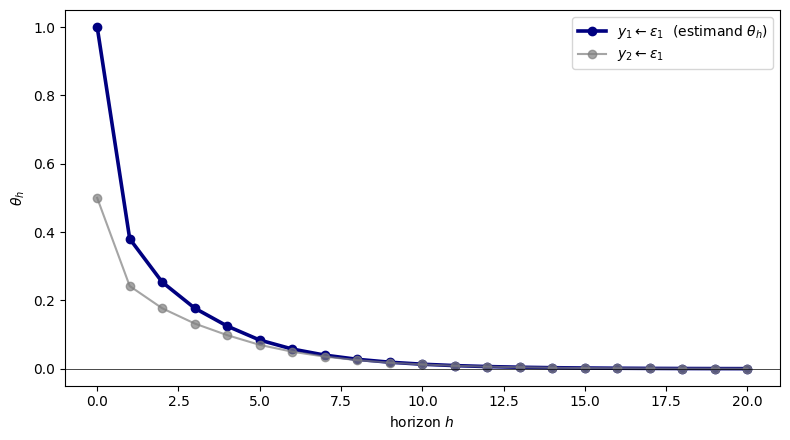

In [4]:
# True structural IRFs (no estimation)
hgrid = np.arange(H + 1)
irf = {(r, m): var_irf(DGP, H, shock=m, response=r) for r in range(2) for m in range(2)}

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(hgrid, irf[(0, 0)], "o-", lw=2.6, color="navy", label=r"$y_1 \leftarrow \varepsilon_1$  (estimand $\theta_h$)")
ax.plot(hgrid, irf[(1, 0)], "o-", lw=1.5, alpha=0.7, color="tab:gray", label=r"$y_2 \leftarrow \varepsilon_1$")
ax.axhline(0, color="k", lw=0.5)
# ax.set_title(f"True IRF — decaying bivariate VAR(4), ρ={RHO} ({Scenario})")
ax.set_xlabel("horizon $h$"); ax.set_ylabel(r"$\theta_h$"); ax.legend()
fig.tight_layout()
plt.savefig(f"../../figures/Base_Case/BASE_IRF_rho={RHO}.png")
plt.show()

## 2. Monte Carlo — LP(4) + VAR(q) sweep across sample sizes

Fixed **LP(4)** vs the full **VAR(q) sweep** (q = 1 … 23), recursive identification, run once **per sample size** $T \in \{100, 250, 500\}$. Same DGP and seed across $T$; the true estimand is $T$-independent. Results are stored in `results_byT` / `rmse_byT`.

In [5]:
VAR_ORDERS = list(range(1, P + H))                  # 1, 2, ..., 22, 23

estimators = {"LP(4)": partial(estimate_lp_irf, p=P, horizon=H)}
estimators.update({f"VAR({q})": partial(estimate_var_irf, p=q, horizon=H) for q in VAR_ORDERS})


def var_dgp(rng, Tlen, spec):
    return simulate_var(spec, Tlen, rng)

truth = var_irf(DGP, H)                              # true estimand, var1 <- shock1 (T-independent)

results_byT, rmse_byT = {}, {}
for Tval in T:
    cfg = MCConfig(n_reps=N_REPS, T=Tval, horizon=H, seed=SEED, n_jobs=-1,
                   progress=True, estimators=estimators)
    res = run(partial(var_dgp, spec=DGP), cfg)
    results_byT[Tval] = res
    rmse_byT[Tval] = {nm: np.sqrt(np.nanmean((st - truth) ** 2, axis=0))
                      for nm, st in res["irfs"].items()}
    fails = {k: v for k, v in res["n_failures"].items() if v}
    print(f"T={Tval:>4}: done  |  failures: {fails or 'none'}")

MC reps: 100%|██████████| 5000/5000 [00:09<00:00, 530.02it/s]


T= 100: done  |  failures: none


MC reps: 100%|██████████| 5000/5000 [00:10<00:00, 471.06it/s]


T= 250: done  |  failures: none


MC reps: 100%|██████████| 5000/5000 [00:11<00:00, 448.24it/s]


T= 500: done  |  failures: none


## 3. RMSE comparison across sample sizes

The **complexity frontier** (horizon-averaged RMSE vs VAR order) with one curve per $T$ and LP(4) as a same-colour dashed reference, then a summary table, then RMSE-by-horizon panels per $T$. As $T$ grows all estimators improve and the curves should compress (toward the population LP = VAR equivalence).

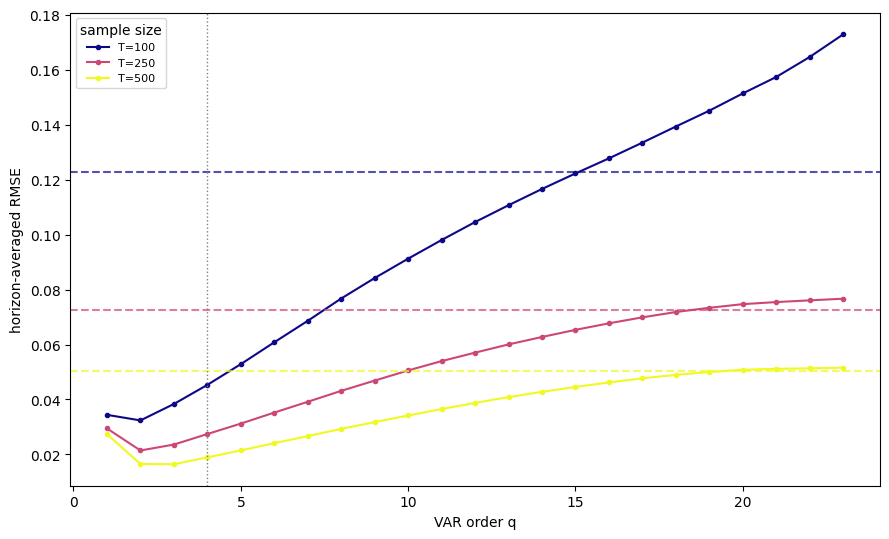

    T    LP(4)   VAR(4)       bestVAR   LP-VAR4
-----------------------------------------------
  100    0.123    0.045  VAR(2)=0.032    +0.078
  250    0.072    0.027  VAR(2)=0.021    +0.045
  500    0.050    0.019  VAR(3)=0.016    +0.032
(horizon-averaged RMSE;  LP-VAR4 > 0 = VAR(4) better)


In [6]:
cT = {Tval: plt.cm.plasma(i / max(len(T) - 1, 1)) for i, Tval in enumerate(T)}

# (1) complexity frontier across T: horizon-averaged RMSE vs VAR order
fig, ax = plt.subplots(figsize=(9, 5.5))
for Tval in T:
    rm = rmse_byT[Tval]
    avg_var = [np.mean(rm[f"VAR({q})"]) for q in VAR_ORDERS]
    ax.plot(VAR_ORDERS, avg_var, "o-", ms=3, color=cT[Tval], label=f"T={Tval}")
    ax.axhline(np.mean(rm["LP(4)"]), ls="--", color=cT[Tval], alpha=0.7)
ax.axvline(4, color="gray", ls=":", lw=1)
# ax.set_title(f"Complexity frontier across T  (solid = VAR(q);  dashed = LP(4), same colour), ρ={RHO} ({Scenario})")
ax.set_xlabel("VAR order q"); ax.set_ylabel("horizon-averaged RMSE")
ax.legend(fontsize=8, title="sample size")
fig.tight_layout()
plt.savefig(f"../../figures/Base_Case/BASE_COMPLEXITY_FRONTIER_rho={RHO}.png")
plt.show()

# (2) summary table across T
print(f"{'T':>5} {'LP(4)':>8} {'VAR(4)':>8} {'bestVAR':>13} {'LP-VAR4':>9}")
print("-" * 47)
for Tval in T:
    rm = rmse_byT[Tval]
    lp = float(np.mean(rm["LP(4)"])); v4 = float(np.mean(rm["VAR(4)"]))
    avgs = {q: float(np.mean(rm[f"VAR({q})"])) for q in VAR_ORDERS}
    bq = min(avgs, key=avgs.get)
    print(f"{Tval:>5} {lp:8.3f} {v4:8.3f} {f'VAR({bq})={avgs[bq]:.3f}':>13} {lp - v4:+9.3f}")
print("(horizon-averaged RMSE;  LP-VAR4 > 0 = VAR(4) better)")

Precise interpretation is dependent on the chosen persistence, but generally we find that VAR(4) outperforms LP(4) in avg RMSE. The best VAR model, defined as the model exhibiting the lowest horizon-averaged RMSE, is 1 or 2 for low persistence, and 3 or 4 for medium to high persistence. Lastly we observe what looks like a convergence of high order VARs to LP(4) performance, when sample size is >250.

### RMSE by horizon, per sample size

One panel per $T$: the VAR sweep (dark = low order → yellow = high), with LP(4) and the equal-lag VAR(4) highlighted.

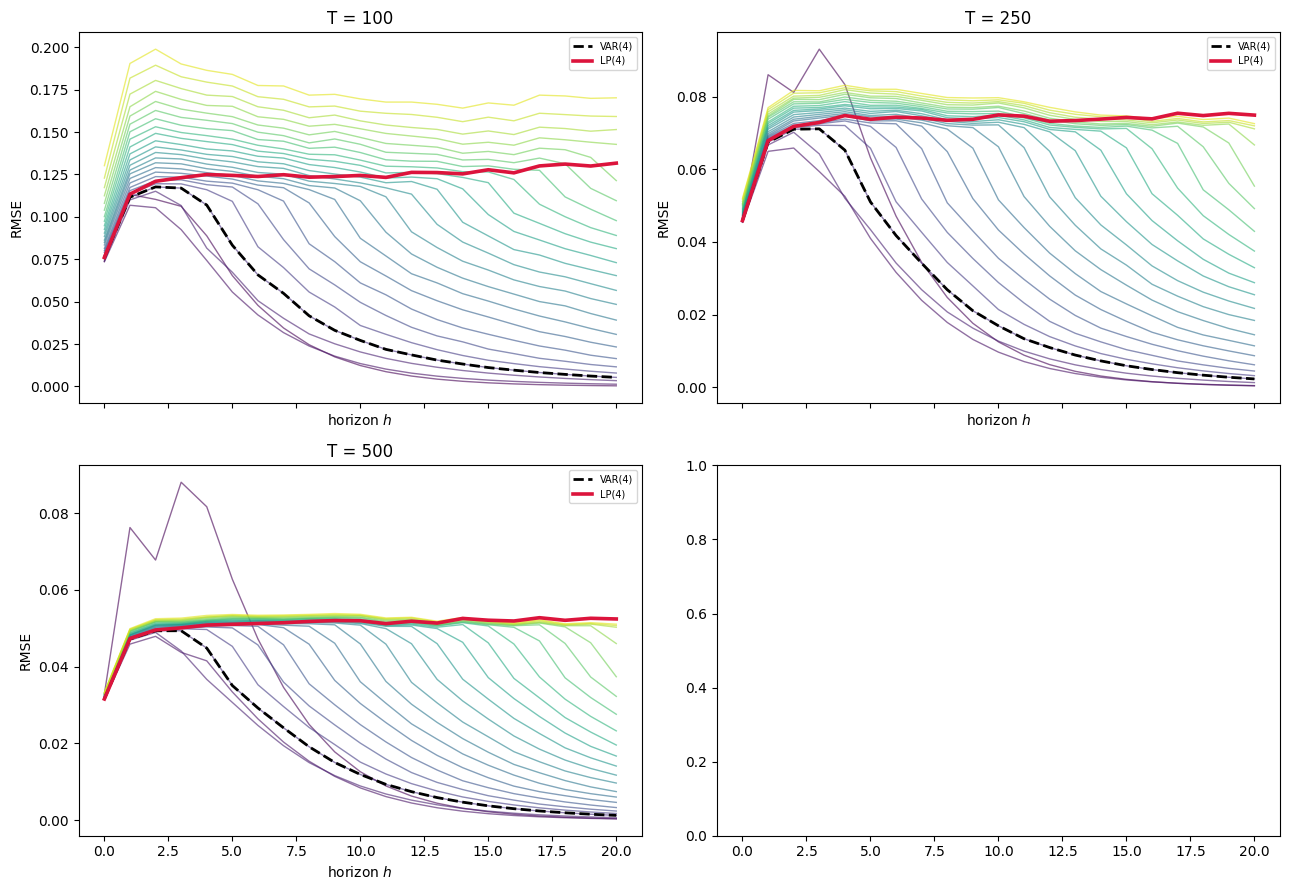

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)
for ax, Tval in zip(axes.ravel(), T):
    rm = rmse_byT[Tval]
    for i, q in enumerate(VAR_ORDERS):
        ax.plot(hgrid, rm[f"VAR({q})"], color=plt.cm.viridis(i / len(VAR_ORDERS)), lw=1, alpha=0.6)
    ax.plot(hgrid, rm["VAR(4)"], "k--", lw=2, label="VAR(4)")
    ax.plot(hgrid, rm["LP(4)"], color="crimson", lw=2.6, label="LP(4)")
    ax.set_title(f"T = {Tval}"); ax.set_xlabel("horizon $h$"); ax.set_ylabel("RMSE"); ax.legend(fontsize=7)
# fig.suptitle(f"RMSE by horizon, by sample size  (VAR sweep: dark = low order -> yellow = high), ρ={RHO} ({Scenario})", fontweight="bold")
fig.tight_layout()
plt.savefig(f"../../figures/Base_Case/BASE_RMSE_BY_HORIZON_rho={RHO}.png")
plt.show()

### Predicted IRF vs the truth (levels, not RMSE)

For each estimator at $T=250$: the **true** IRF $\theta_h$ (dashed black), the **mean** estimated IRF across replications (solid), and the **central 90% band** (5th–95th percentile of $\hat\theta_h^{(b)}$). The gap between the solid line and the dashed line is *bias*; the width of the band is *dispersion* (≈ variance) — the two ingredients of RMSE, shown directly as predictions.

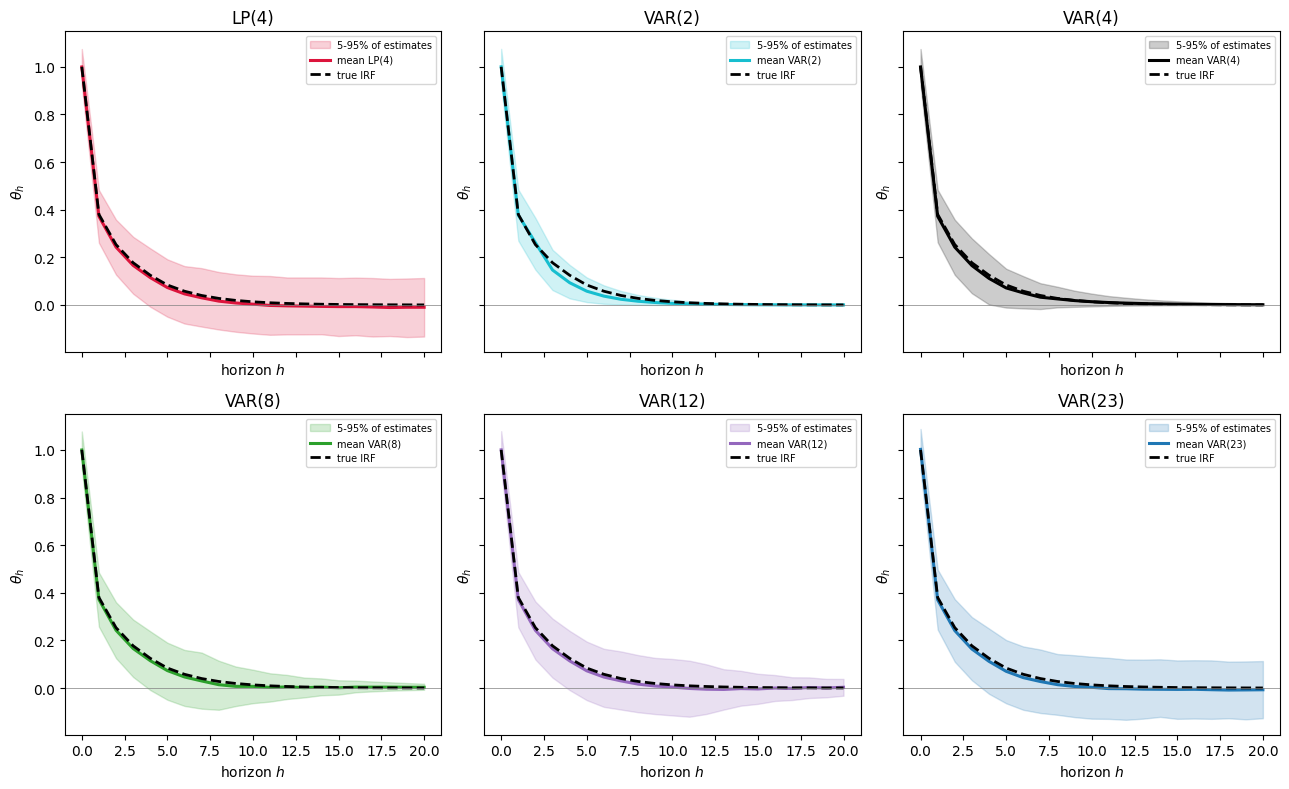

In [8]:
Tval = 250
sel = ["LP(4)", "VAR(2)", "VAR(4)", "VAR(8)", "VAR(12)", "VAR(23)"]      # LP + under- / well- / over-fit VAR
colp = {"LP(4)": "crimson", "VAR(2)": "tab:cyan", "VAR(4)": "black", "VAR(8)": "tab:green", "VAR(12)": "tab:purple", "VAR(23)": "tab:blue", }

fig, axes = plt.subplots(2, 3, figsize=(13, 8), sharex=True, sharey=True)
for ax, nm in zip(axes.ravel(), sel):
    stack = results_byT[Tval]["irfs"][nm]              # (B, H+1) estimated IRFs across reps
    mean = np.nanmean(stack, axis=0)                   # average prediction at each horizon
    lo, hi = np.nanpercentile(stack, [5, 95], axis=0)  # central 90% of the predictions
    ax.fill_between(hgrid, lo, hi, color=colp[nm], alpha=0.2, label="5-95% of estimates")
    ax.plot(hgrid, mean, color=colp[nm], lw=2.2, label=f"mean {nm}")
    ax.plot(hgrid, truth, "k--", lw=2.0, label="true IRF")
    ax.axhline(0, color="gray", lw=0.5)
    ax.set_title(nm); ax.set_xlabel("horizon $h$"); ax.set_ylabel(r"$\theta_h$")
    ax.legend(fontsize=7)
# fig.suptitle(f"Predicted IRF vs truth — T={Tval}, B={N_REPS}  (band = central 90% of replications), ρ={RHO} ({Scenario})",
#             fontweight="bold")
fig.tight_layout()
plt.savefig(f"../../figures/Base_Case/BASE_PREDICTED_VS_TRUTH_IRF_rho={RHO}_T={Tval}_B=5000.png")
plt.show()

## 4. Point-estimation metrics (Ch. 3)

Per horizon $h$, across $B$ replications, relative to the true estimand $\theta_h$:

$$\widehat{\mathrm{Bias}}_h=\tfrac1B\sum_b(\hat\theta_h^{(b)}-\theta_h),\quad
\widehat{\mathrm{Var}}_h=\tfrac1{B-1}\sum_b(\hat\theta_h^{(b)}-\bar{\hat\theta}_h)^2,\quad
\widehat{\mathrm{MSE}}_h=\tfrac1B\sum_b(\hat\theta_h^{(b)}-\theta_h)^2,\quad
\widehat{\mathrm{RMSE}}_h=\sqrt{\widehat{\mathrm{MSE}}_h}$$

with $\mathrm{MSE}_h=\mathrm{Bias}_h^2+\mathrm{Var}_h$ and Monte-Carlo standard error $\mathrm{MCSE}(\widehat{\mathrm{Bias}}_h)=\sqrt{\widehat{\mathrm{Var}}_h/B}$ to quantify simulation uncertainty. Shown at $T=250$ for LP(4), VAR(2), VAR(4), VAR(8), VAR(16), VAR(23).

*(The second Ch. 3 dimension — coverage of nominal 95% CIs, via the VAR(q) delta method and LP heteroskedasticity-robust SEs — needs per-replication interval machinery and is built separately.)*

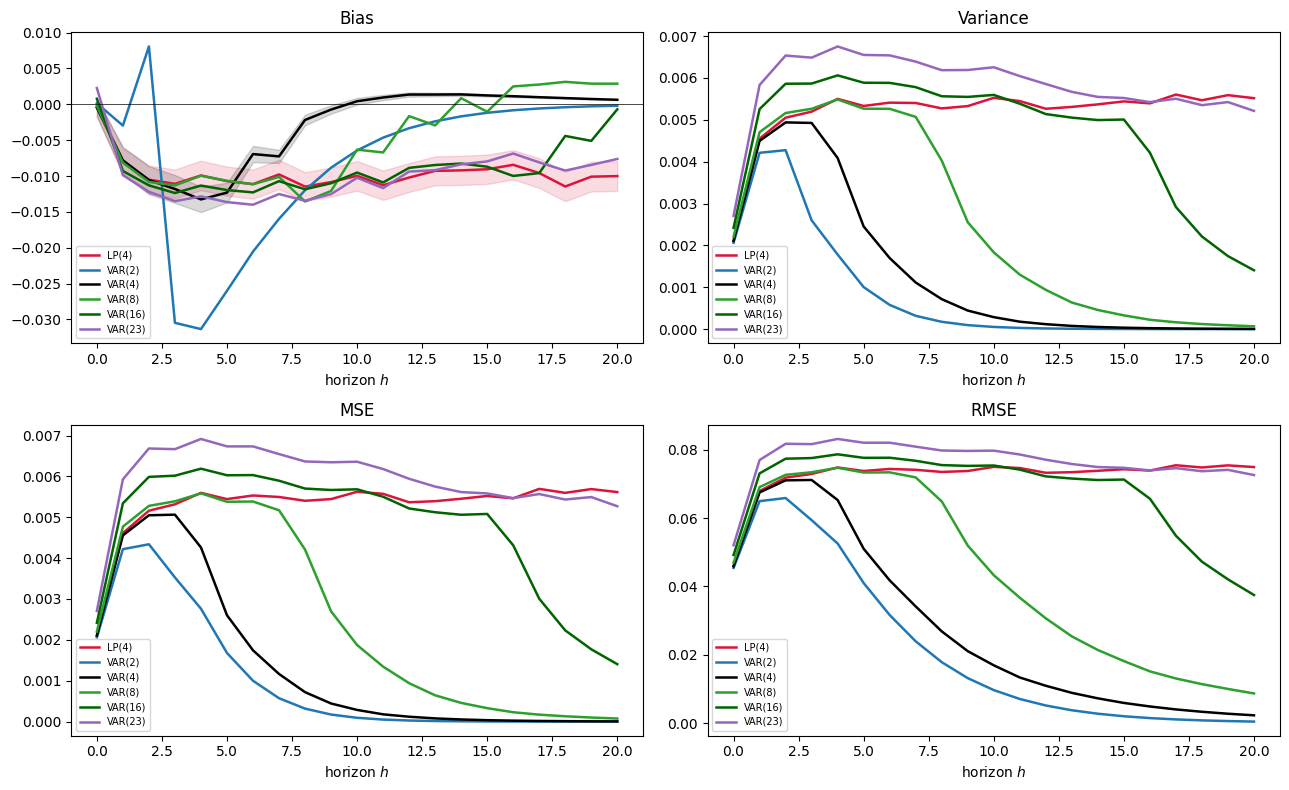

T=250,  B=5000   |   typical MCSE(bias) ~ 0.0005


h=1             h=8            h=20        
           bias    RMSE    bias    RMSE    bias    RMSE
LP(4)   -0.0079  0.0679 -0.0115  0.0735 -0.0100  0.0749
VAR(2)  -0.0030  0.0650 -0.0120  0.0178 -0.0002  0.0004
VAR(4)  -0.0078  0.0675 -0.0022  0.0268  0.0006  0.0023
VAR(8)  -0.0081  0.0691 -0.0136  0.0649  0.0029  0.0087
VAR(16) -0.0093  0.0731 -0.0119  0.0755 -0.0007  0.0375
VAR(23) -0.0099  0.0770 -0.0135  0.0798 -0.0076  0.0726

In [9]:
import pandas as pd
from IPython.display import display


def metrics(stack, truth):
    """Per-horizon Ch. 3 point metrics for a (B, H+1) stack of IRF estimates."""
    B = int(np.sum(~np.isnan(stack[:, 0])))
    mean = np.nanmean(stack, axis=0)
    bias = mean - truth
    var = np.nanvar(stack, axis=0, ddof=1)
    mse = np.nanmean((stack - truth) ** 2, axis=0)
    return dict(bias=bias, var=var, mse=mse, rmse=np.sqrt(mse),
                mcse_bias=np.sqrt(var / B), B=B)


Tval = 250
sel = ["LP(4)", "VAR(2)", "VAR(4)", "VAR(8)", "VAR(16)", "VAR(23)"]
colm = {"LP(4)": "crimson", "VAR(2)": "tab:blue", "VAR(4)": "black",
        "VAR(8)": "tab:green", "VAR(16)": "darkgreen", "VAR(23)": "tab:purple"}
m = {nm: metrics(results_byT[Tval]["irfs"][nm], truth) for nm in sel}

fig, ax = plt.subplots(2, 2, figsize=(13, 8))
for nm in sel:
    ax[0, 0].plot(hgrid, m[nm]["bias"], color=colm[nm], lw=1.8, label=nm)
    ax[0, 1].plot(hgrid, m[nm]["var"], color=colm[nm], lw=1.8, label=nm)
    ax[1, 0].plot(hgrid, m[nm]["mse"], color=colm[nm], lw=1.8, label=nm)
    ax[1, 1].plot(hgrid, m[nm]["rmse"], color=colm[nm], lw=1.8, label=nm)
for nm in ("LP(4)", "VAR(4)"):                       # MCSE band on bias (sim. uncertainty)
    lo, hi = m[nm]["bias"] - 1.96 * m[nm]["mcse_bias"], m[nm]["bias"] + 1.96 * m[nm]["mcse_bias"]
    ax[0, 0].fill_between(hgrid, lo, hi, color=colm[nm], alpha=0.15)
ax[0, 0].axhline(0, color="k", lw=0.5)
ax[0, 0].set_title("Bias")
ax[0, 1].set_title("Variance"); ax[1, 0].set_title("MSE"); ax[1, 1].set_title("RMSE")
for a in ax.ravel():
    a.set_xlabel("horizon $h$"); a.legend(fontsize=7)
# fig.suptitle(f"Ch. 3 point-estimation metrics — T={Tval}, B={N_REPS}, ρ={RHO} ({Scenario})", fontweight="bold")
fig.tight_layout()
plt.savefig(f"../../figures/Base_Case/BASE_POINT_ESTIMATION_rho={RHO}_T={Tval}_B=5000.png")
plt.show()

# compact table: bias and RMSE at selected horizons
report = [1, 8, 20]
rows = {nm: {(f"h={h}", k): m[nm][{"bias": "bias", "RMSE": "rmse"}[k]][h]
             for h in report for k in ("bias", "RMSE")} for nm in sel}
tab = pd.DataFrame(rows).T
tab.columns = pd.MultiIndex.from_tuples(tab.columns)
print(f"T={Tval},  B={N_REPS}   |   typical MCSE(bias) ~ "
      f"{np.mean([m['VAR(4)']['mcse_bias'][h] for h in report]):.4f}")
display(tab.round(4))

## 5. Coverage of nominal 95% confidence intervals (Ch. 3)

The second Ch. 3 dimension. For each replication we build a 95% CI for $\theta_h$ and record whether it contains the **true** $\theta_h$; coverage is the fraction that do, $\widehat{\mathrm{Coverage}}_h=\tfrac1B\sum_b \mathbf 1[\theta_h\in \hat{CI}_h^{(b)}]$. A well-calibrated estimator gives ≈ 0.95 at every horizon.

Two CI constructions, exactly as Ch. 3 specifies:

* **VAR(q): delta method.** $\hat\theta_h=\hat\Psi_h\hat B e_1$ is a smooth function of the reduced-form coefficients $\hat A$. We propagate $\mathrm{Cov}(\hat A)$ through that map: $\mathrm{Var}(\hat\theta_h)\approx d_h'\,\Sigma_\alpha\,d_h$, where $d_h=\partial\theta_h/\partial\alpha$ comes from differentiating the MA recursion and $\Sigma_\alpha=\Sigma_u\otimes(X'X)^{-1}$ is the OLS coefficient covariance. Identification ($B$) is held fixed, as the thesis states ("propagating uncertainty in the reduced-form coefficients").
* **LP(4): heteroskedasticity-robust (HC) SE** of the shock coefficient $\hat\beta_h$. Plain White SE (not HAC) suffices because the structural shock is a martingale-difference regressor (Plagborg-Møller & Wolf).

We **validate** the delta method by checking its SE against the empirical sampling SD of $\hat\theta_h$ across replications — they should match.

coverage MC: 100%|██████████| 5000/5000 [00:42<00:00, 118.22it/s]


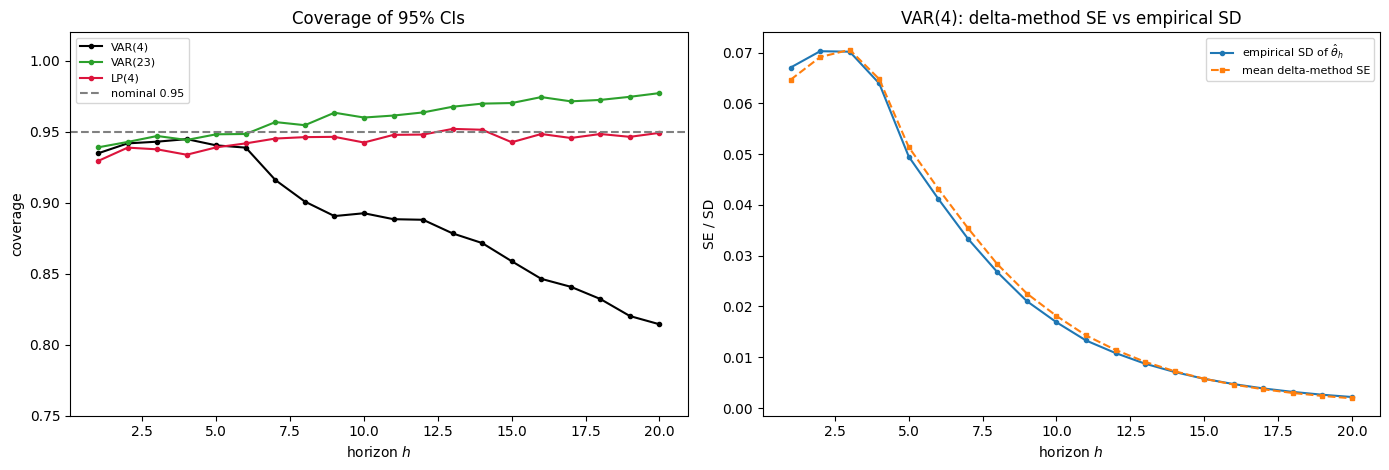

horizon-averaged coverage (h=1..20):  VAR(4)=0.889   VAR(23)=0.960   LP(4)=0.944


In [10]:
from joblib import Parallel, delayed
from tqdm import tqdm
from mcsim.coverage import var_theta_se, lp_theta_se

T_COV = 250            # one sample-size cell (Ch. 3 would sweep T as in section 2)
N_COV = 5000           # replications for the coverage MC
Z = 1.96               # normal critical value for a nominal 95% two-sided CI
EST_COV = ["VAR(4)", "VAR(23)", "LP(4)"]


def _coverage_rep(seed):
    """One replication: simulate, then return {estimator: (theta_hat, se)}."""
    rng = np.random.default_rng(seed)
    y = simulate_var(DGP, T_COV, rng)
    with np.errstate(divide="ignore", over="ignore", invalid="ignore"):
            return {"VAR(4)": var_theta_se(y, 4, H),
                "VAR(23)": var_theta_se(y, 23, H),
                "LP(4)":  lp_theta_se(y, 4, H)}

# Independent, reproducible RNG stream per replication (parallel-safe), as in mcsim.run.
seeds = np.random.SeedSequence(SEED).spawn(N_COV)
reps_out = Parallel(n_jobs=-1)(delayed(_coverage_rep)(s) for s in tqdm(seeds, desc="coverage MC"))

# Stack per estimator: theta and se are (N_COV, H+1).
theta_s = {nm: np.array([r[nm][0] for r in reps_out]) for nm in EST_COV}
se_s = {nm: np.array([r[nm][1] for r in reps_out]) for nm in EST_COV}

# Coverage_h = fraction of CIs [theta_hat +/- Z*se] that contain the TRUE theta_h.
coverage = {nm: np.nanmean((theta_s[nm] - Z * se_s[nm] <= truth) &
                           (truth <= theta_s[nm] + Z * se_s[nm]), axis=0) for nm in EST_COV}

# --- Validation: delta-method SE should match the empirical sampling SD ----------
val_emp = np.nanstd(theta_s["VAR(4)"], axis=0, ddof=1)
val_se = np.nanmean(se_s["VAR(4)"], axis=0)

fig, (axc, axv) = plt.subplots(1, 2, figsize=(14, 4.8))
# fig.suptitle(f"Coverage Analysis, ρ={RHO} ({Scenario})", fontweight="bold")
cc = {"VAR(4)": "black", "VAR(23)": "tab:green", "LP(4)": "crimson"}
_ylo = float(max(0.0, np.floor((min(np.nanmin(coverage[nm][1:]) for nm in EST_COV) - 0.02) * 20) / 20))
for nm in EST_COV:
    axc.plot(hgrid[1:], coverage[nm][1:], "o-", ms=3, color=cc[nm], label=nm)
axc.axhline(0.95, color="gray", ls="--", label="nominal 0.95")
axc.set_ylim(_ylo, 1.02); axc.set_xlabel("horizon $h$"); axc.set_ylabel("coverage")
axc.set_title(f"Coverage of 95% CIs"); axc.legend(fontsize=8)

axv.plot(hgrid[1:], val_emp[1:], "o-", ms=3, label="empirical SD of $\\hat\\theta_h$")
axv.plot(hgrid[1:], val_se[1:], "s--", ms=3, label="mean delta-method SE")
axv.set_xlabel("horizon $h$"); axv.set_ylabel("SE / SD"); axv.set_title("VAR(4): delta-method SE vs empirical SD")
axv.legend(fontsize=8)
fig.tight_layout()
plt.savefig(f"../../figures/Base_Case/BASE_COVERAGE_rho={RHO}_T=250_B=5000.png")
plt.show()

print(f"horizon-averaged coverage (h=1..{H}):  " +
      "   ".join(f"{nm}={np.nanmean(coverage[nm][1:]):.3f}" for nm in EST_COV))

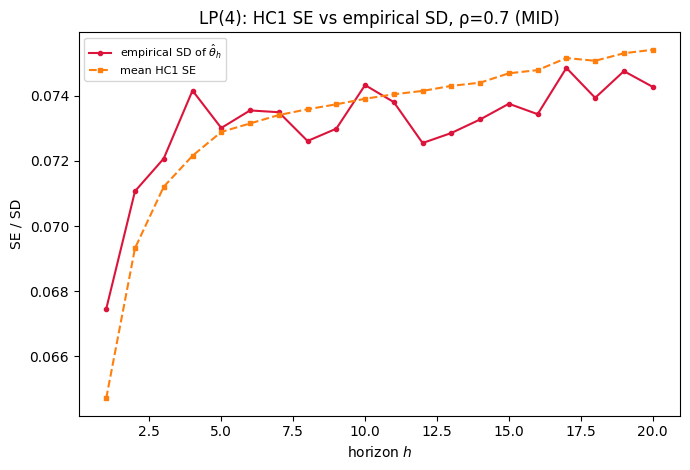

LP(4) mean HC1 SE / empirical SD:  h=1:0.96   h=10:0.99   h=20:1.02


In [11]:
# --- LP(4) SE diagnostic: HC1 SE vs empirical sampling SD ------------------------
# HC1 is exact for the impact response but ignores the serial correlation LP residuals
# carry at h>0 (Plagborg-Moller & Wolf), so it can under-state uncertainty as the
# horizon grows.  Comparing the mean reported HC1 SE to the Monte Carlo SD of
# theta_hat quantifies that gap directly (coverage reflects it only indirectly).
lp_emp = np.nanstd(theta_s["LP(4)"], axis=0, ddof=1)   # Monte Carlo sampling SD (the target)
lp_se = np.nanmean(se_s["LP(4)"], axis=0)              # mean reported HC1 SE

fig, ax = plt.subplots(figsize=(7, 4.8))
ax.plot(hgrid[1:], lp_emp[1:], "o-", ms=3, color="crimson", label="empirical SD of $\\hat\\theta_h$")
ax.plot(hgrid[1:], lp_se[1:], "s--", ms=3, color="tab:orange", label="mean HC1 SE")
ax.set_xlabel("horizon $h$"); ax.set_ylabel("SE / SD")
ax.set_title(f"LP(4): HC1 SE vs empirical SD, ρ={RHO} ({Scenario})")
ax.legend(fontsize=8); fig.tight_layout()
plt.savefig(f"../../figures/Base_Case/BASE_LP_SE_VALIDATION_rho={RHO}_T=250_B=5000.png")
plt.show()

print("LP(4) mean HC1 SE / empirical SD:  " +
      "   ".join(f"h={h}:{lp_se[h]/lp_emp[h]:.2f}" for h in (1, H // 2, H)))